# Wiskunde II — Portfolio-opdracht: CO₂-uitstoot en mobiliteit

**Groep 25:** Melih Bağci · Jafari Deul · Thomas Keus

**Deadline notebook (Brightspace):** zondag 21 juni, 23:59 — voorwaardelijk voor het assessment.

**Handgeschreven verslag:** 1 per groep, inleveren bij het assessment. Alle verslagvragen staan verzameld in het hoofdstuk **Verslag** onderaan dit notebook. Daar werken we de antwoorden samen uit; 1 persoon schrijft ze daarna over op papier.

## Hoofdvragen van het portfolio
1. Welke persoonlijke en mobiliteitsgerelateerde factoren verklaren verschillen in de jaarlijkse CO₂-uitstoot tussen burgers?
2. In welke mate kunnen we individuele uitstoot nauwkeurig voorspellen op basis van een combinatie van sociaaldemografische kenmerken en mobiliteitsgedrag?

## Taakverdeling

| Deel | Onderwerp | Python-opdrachten | Verslagvragen | Wie |
|---|---|---|---|---|
| 0 | Setup & data inladen | — | — | samen |
| 1 | Beschrijvende statistiek & opschonen | A, B | 1, 2, 3 | **Melih** |
| 2 | Verdelingen & normaliteit | C, D | 4, 5 | **Melih** |
| 3 | Transformatie & relaties | E, F | 6, 7, 8 | **Jafari** |
| 4 | Kansrekening | G | 9 | **Jafari** |
| 5 | Hypothesetoetsing (groepsverschil) | H, I | 10–14 | **Jafari** |
| 6 | Lineaire regressie | J, K, L | 15, 16, 17 | **Thomas** |
| 7 | Modelvergelijking (20-fold CV) | M, N, O, P | 18, 19 | **Thomas** |
| 8 | Classificatie | Q, R | 20, 21 | **Melih** |
| 9 | Conclusie | — | 22 | samen |

Wie een deel doet, vult ook de bijbehorende verslagvragen in (hoofdstuk **Verslag** onderaan). 1 persoon schrijft het verslag daarna handgeschreven uit.

**Assessment:** ieder krijgt 5 vragen, 1 per leerdoel, over het hele portfolio. Iedereen moet dus alle delen begrijpen. Plan een gezamenlijke doorloopsessie voor het assessment.

### Leerdoelen (beoordelingsmodel, max 50 punten)
1. Beschrijvende statistieken berekenen en interpreteren (10 pt) — Deel 1
2. Correlatie & regressie opstellen en interpreteren (10 pt) — Deel 3, 6
3. Regels van kansrekening toepassen (5 pt) — Deel 4, vraag 15
4. Verdeling visualiseren en interpreteren (10 pt) — Deel 2, 5, 7
5. Geschikte statistische toets kiezen, uitvoeren, interpreteren (15 pt) — Deel 2, 5, 7

---
## Deel 0 — Setup & data inladen *(samen)*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

df = pd.read_excel("Mobiliteitsdata.xlsx")
print(df.shape)
df.head()

(1500, 22)


,persoon_ID,geslacht,leeftijd,gewicht_KG,burgerlijke_staat,jaarsalaris_eu,huishouden_grootte,stad,provincie,opleiding_niveau,autobezit,fietsbezit,elektrisch_auto,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG
0,811069,man,50,52.66,weduwe/weduwnaar,48003.64,5,Almere,Flevoland,MBO,ja,ja,nee,13266.05,2040.54,3227.95,480.71,4,1,20,Nooit,7591.93
1,246882,vrouw,65,64.58,samenwonend,55208.63,2,Leeuwarden,Overijssel,WO,ja,nee,nee,15229.89,0.00,2298.96,1423.34,5,0,7,Heel soms,8742.25
2,978385,man,49,90.87,samenwonend,29533.78,2,Tilburg,Utrecht,HBO,ja,ja,ja,19853.24,1540.46,4504.21,632.48,4,1,2,Altijd,4513.56
3,120468,man,34,80.43,gehuwd,44453.27,2,Maastricht,Utrecht,HBO,ja,ja,nee,9935.50,1825.92,4407.56,1266.84,3,2,21,Heel soms,6904.41
4,637034,man,60,72.28,ongehuwd,56497.64,2,Leiden,Gelderland,MBO,ja,ja,ja,16266.67,1851.07,1936.12,1676.00,0,5,0,Nooit,4420.80


---
## Deel 1 — Beschrijvende statistiek & opschonen *(Melih)*

### A — Bepaal voor elke kolom de relevante beschrijvende statistieken
*Relevant = passend bij het meetniveau: numeriek → gemiddelde, mediaan, std, kwartielen, min/max; categoriaal → frequenties/modus.*

In [2]:
# numerieke kolommen
df.describe()

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,co2_uitstoot_per_jaar_KG
count,1500.000000,1500.000000,1500.00000,1499.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1493.000000
mean,560229.090000,47.989333,75.14630,40092.551094,3.032000,8597.262393,1794.180353,2942.222840,1072.277327,2.532667,2.467333,14.485333,4912.341875
std,260939.294996,18.134915,14.79674,14986.839768,1.411017,7021.428530,753.991154,1531.377214,748.651072,1.671365,1.671365,8.700819,3422.902397
min,102295.000000,0.000000,0.00000,-8505.150000,1.000000,-6506.630000,0.000000,-2264.780000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,332525.750000,32.000000,65.63500,30008.920000,2.000000,0.000000,1503.420000,1950.682500,471.540000,1.000000,1.000000,7.000000,1469.450000
50%,563847.000000,47.000000,75.79000,40503.080000,3.000000,9356.380000,1910.005000,2987.030000,1052.140000,3.000000,2.000000,15.000000,4677.280000
75%,792686.750000,64.000000,84.93500,50281.165000,4.000000,13842.732500,2286.180000,3991.537500,1588.555000,4.000000,4.000000,22.000000,7481.550000
max,999493.000000,79.000000,117.76000,93826.850000,5.000000,34618.870000,3672.700000,8018.060000,3808.200000,5.000000,5.000000,29.000000,18098.440000


In [3]:
# Overzicht van categorische kolommen en hun frequenties
for kol in df.select_dtypes(include="object"):
    print(kol)
    print(df[kol].value_counts())

geslacht
geslacht
vrouw     778
man       720
anders      2
Name: count, dtype: int64
burgerlijke_staat
burgerlijke_staat
gehuwd              312
ongehuwd            310
gescheiden          310
weduwe/weduwnaar    287
samenwonend         281
Name: count, dtype: int64
stad
stad
Breda         72
Amsterdam     72
Nijmegen      67
Utrecht       67
Enschede      67
Venlo         66
Leeuwarden    62
Tilburg       62
Den Bosch     62
Middelburg    62
Maastricht    61
Leiden        61
Groningen     60
Eindhoven     60
Zutphen       60
Amersfoort    59
Rotterdam     57
Zwolle        56
Haarlem       54
Apeldoorn     54
Delft         54
Arnhem        53
Hoofddorp     52
Assen         51
Almere        48
Name: count, dtype: int64
provincie
provincie
Groningen        157
Flevoland        142
Limburg          140
Zeeland          130
Drenthe          125
Noord-Holland    125
Overijssel       124
Utrecht          118
Friesland        118
Gelderland       111
Noord-Brabant    106
Zuid-Holland     104

C:\Users\thoma\AppData\Local\Temp\ipykernel_44816\3625361090.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for kol in df.select_dtypes(include="object"):


### B — Missende / niet-kloppende / extreme waarden opsporen en adequaat afhandelen

Checklist:
- [ ] Missende waarden: `df.isna().sum()`
- [ ] Niet-kloppende waarden: stad/provincie-combinaties kloppen niet altijd (bv. rij met Leeuwarden in "Overijssel" — hoort Friesland te zijn). Check ook: negatieve km's, gewicht/leeftijd buiten realistische range, thuiswerk + kantoor > 5 dagen, km_auto > 0 terwijl autobezit = nee?
- [ ] Extreme waarden (outliers): boxplots / IQR-regel / z-scores
- [ ] Keuze documenteren: verwijderen, corrigeren of imputeren — en waarom (nodig voor verslagvraag 3)

In [4]:
# Aantal missende waarden per variabele
df.isna().sum()

persoon_ID                               0
geslacht                                 0
leeftijd                                 0
gewicht_KG                               0
burgerlijke_staat                        0
jaarsalaris_eu                           1
huishouden_grootte                       0
stad                                     1
provincie                                0
opleiding_niveau                         1
autobezit                                1
fietsbezit                               0
elektrisch_auto                          0
km_auto_per_jaar                         0
km_fiets_per_jaar                        0
km_ov_per_jaar                           0
km_vliegtuig_per_jaar                    0
dagen_thuiswerken_per_week_pro_rato      0
dagen_kantoorwerken_per_week_pro_rato    0
dagen_in_buitenland_per_jaar             0
gebruik_carsharing                       0
co2_uitstoot_per_jaar_KG                 7
dtype: int64

In [5]:
# controleren op niet kloppende waarden
for kol in ["km_auto_per_jaar", "km_ov_per_jaar", "km_fiets_per_jaar", "km_vliegtuig_per_jaar"]:
    print(f"Negatieve {kol}:", (df[kol] < 0).sum())

print("Leeftijd < 16 of > 120:",
      ((df["leeftijd"] < 16) | (df["leeftijd"] > 120)).sum())

print("Gewicht < 30 of > 250:",
      ((df["gewicht_KG"] < 30) | (df["gewicht_KG"] > 250)).sum())

Negatieve km_auto_per_jaar: 12
Negatieve km_ov_per_jaar: 41
Negatieve km_fiets_per_jaar: 0
Negatieve km_vliegtuig_per_jaar: 0
Leeftijd < 16 of > 120: 1
Gewicht < 30 of > 250: 6


In [6]:
# extreme waarden opsporen met de IQR-methode
print("Aantal outliers per variabele:\n")
for kol in df.select_dtypes(include="number"):
    q1 = df[kol].quantile(0.25)
    q3 = df[kol].quantile(0.75)
    iqr = q3 - q1

    outliers = ((df[kol] < q1 - 1.5*iqr) |
                (df[kol] > q3 + 1.5*iqr)).sum()

    print(f"{kol}: {outliers} outliers")

Aantal outliers per variabele:

persoon_ID: 0 outliers
leeftijd: 0 outliers
gewicht_KG: 15 outliers
jaarsalaris_eu: 11 outliers
huishouden_grootte: 0 outliers
km_auto_per_jaar: 1 outliers
km_fiets_per_jaar: 149 outliers
km_ov_per_jaar: 13 outliers
km_vliegtuig_per_jaar: 3 outliers
dagen_thuiswerken_per_week_pro_rato: 0 outliers
dagen_kantoorwerken_per_week_pro_rato: 0 outliers
dagen_in_buitenland_per_jaar: 0 outliers
co2_uitstoot_per_jaar_KG: 1 outliers


In [7]:
# Kopie van de originele dataset (origineel df blijft behouden)
df_clean = df.copy()

# 1) Niet-kloppende NEGATIEVE kilometers -> NaN (kan fysiek niet < 0)
for kol in ["km_auto_per_jaar", "km_ov_per_jaar", "km_fiets_per_jaar", "km_vliegtuig_per_jaar"]:
    df_clean.loc[df_clean[kol] < 0, kol] = np.nan

# 2) Onmogelijke jaarsalaris (< 0) -> NaN
df_clean.loc[df_clean["jaarsalaris_eu"] < 0, "jaarsalaris_eu"] = np.nan

# 3) Onmogelijk gewicht (< 30 of > 250 kg) -> NaN
df_clean.loc[(df_clean["gewicht_KG"] < 30) | (df_clean["gewicht_KG"] > 250), "gewicht_KG"] = np.nan

# 3b) Onmogelijke leeftijd (< 16 of > 120) -> NaN
#     (leeftijd 0 hoort niet bij een burger met salaris/mobiliteit)
df_clean.loc[(df_clean["leeftijd"] < 16) | (df_clean["leeftijd"] > 120), "leeftijd"] = np.nan

# 4) Imputeren van numerieke missers met de mediaan (robuust tegen scheve verdeling/outliers)
num_imputeren = ["km_auto_per_jaar", "km_ov_per_jaar", "km_fiets_per_jaar",
                 "km_vliegtuig_per_jaar", "jaarsalaris_eu", "gewicht_KG", "leeftijd"]
for kol in num_imputeren:
    df_clean[kol] = df_clean[kol].fillna(df_clean[kol].median())
df_clean["leeftijd"] = df_clean["leeftijd"].round().astype(int)

# 5) Categorische missers (autobezit, opleiding_niveau, stad) -> modus
for kol in ["autobezit", "opleiding_niveau", "stad"]:
    df_clean[kol] = df_clean[kol].fillna(df_clean[kol].mode()[0])

# 6) Missende TARGET (co2) niet imputeren -> rijen verwijderen (mag niet verzinnen)
df_clean = df_clean.dropna(subset=["co2_uitstoot_per_jaar_KG"]).reset_index(drop=True)

# IQR-outliers laten we staan: het zijn echte veelfietsers/frequent flyers, geen fouten.
# Alleen onmogelijke waarden (negatief / buiten range) hebben we hierboven gefixt.

# Controle: geen missers en geen negatieve km/salaris meer
print("Rijen na opschonen:", len(df_clean), "(was", len(df), ")")
print("Resterende missers:", df_clean.isna().sum().sum())
print("Negatieve km/salaris:", (df_clean[num_imputeren] < 0).sum().sum())

Rijen na opschonen: 1493 (was 1500 )
Resterende missers: 0
Negatieve km/salaris: 0


---
## Deel 2 — Verdelingen & normaliteit *(Melih)*

### C — Kies 2 onafhankelijke variabelen met (verwachte) invloed op CO₂-uitstoot; visualiseer hun verdeling én die van de afhankelijke variabele
*Kies numerieke variabelen (bv. `km_auto_per_jaar` en `km_vliegtuig_per_jaar`) — dan kun je in D ook op normaliteit toetsen. Histogram + KDE per variabele = 3 plots.*

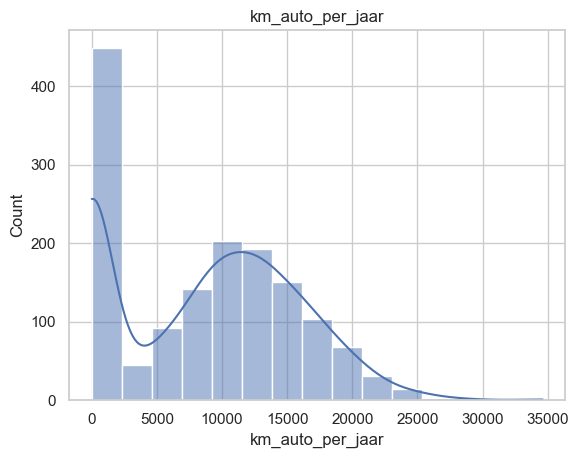

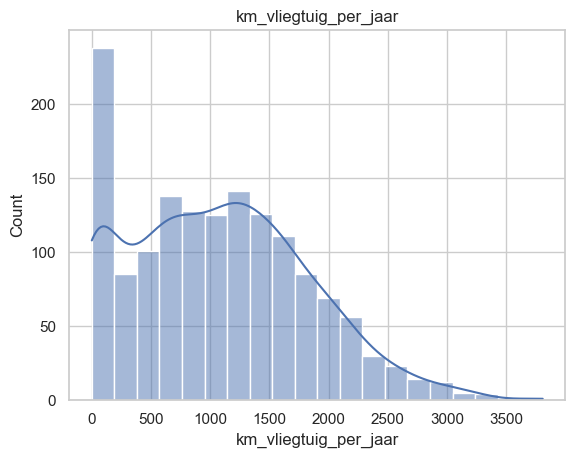

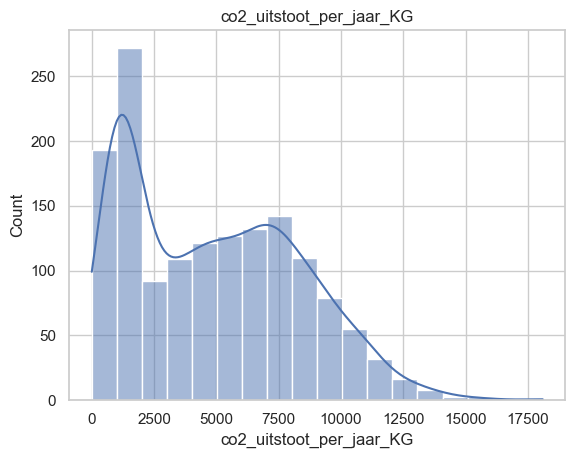

In [8]:
# Verdelingen van de gekozen variabelen
var1 = "km_auto_per_jaar"       
var2 = "km_vliegtuig_per_jaar"  
target = "co2_uitstoot_per_jaar_KG"

sns.histplot(df_clean[var1], kde=True)
plt.title(var1)
plt.show()

sns.histplot(df_clean[var2], kde=True)
plt.title(var2)
plt.show()

sns.histplot(df_clean[target], kde=True)
plt.title(target)
plt.show()

### D — Toets statistisch of de drie verdelingen normaal verdeeld zijn


In [9]:
# Statistische normaliteitstoets (Shapiro-Wilk) op de 3 verdelingen
# H0: de variabele is normaal verdeeld.  alfa = 0.05
# p < 0.05 -> H0 verwerpen -> NIET normaal verdeeld.
alfa = 0.05
for kol in [var1, var2, target]:
    stat, p = stats.shapiro(df_clean[kol])
    conclusie = "niet normaal" if p < alfa else "normaal"
    print(f"{kol}: W = {stat:.4f}, p = {p:.4g} -> {conclusie}")

km_auto_per_jaar: W = 0.9152, p = 4.134e-28 -> niet normaal
km_vliegtuig_per_jaar: W = 0.9652, p = 1.866e-18 -> niet normaal
co2_uitstoot_per_jaar_KG: W = 0.9391, p = 2.769e-24 -> niet normaal


De normaliteit van `km_auto_per_jaar`, `km_vliegtuig_per_jaar` en `co2_uitstoot_per_jaar_KG` is statistisch getoetst met de **Shapiro-Wilk-toets** (H0: normaal verdeeld, α = 0,05) en visueel ondersteund met histogrammen en boxplots. Voor alle drie de variabelen geldt p < 0,05, dus H0 wordt verworpen: de verdelingen zijn **niet normaal verdeeld**. Dit komt overeen met het visuele beeld: de histogrammen zijn rechts-scheef en de boxplots tonen meerdere uitschieters en langere rechterstaarten.

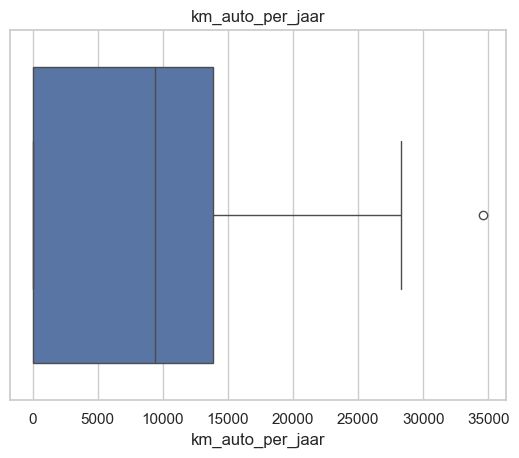

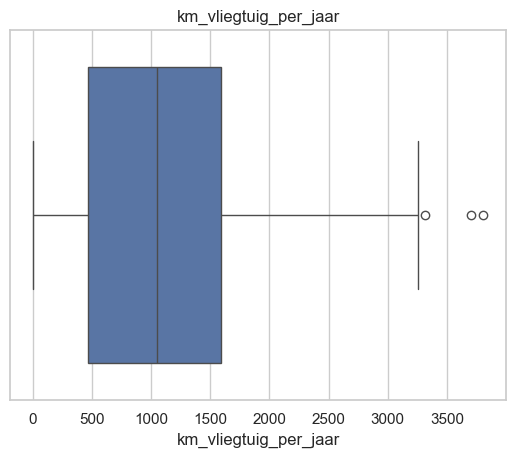

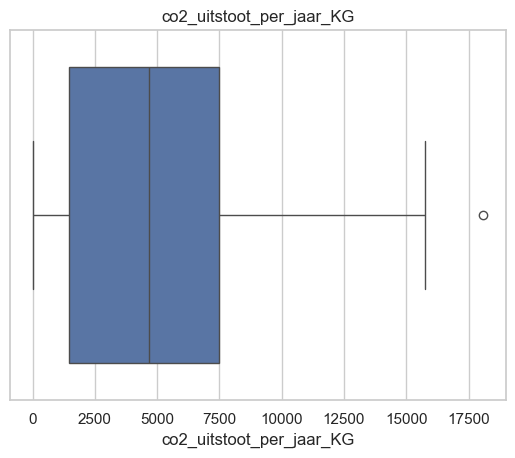

In [10]:
# Boxplots van de gekozen variabelen
sns.boxplot(x=df_clean[var1])
plt.title(var1)
plt.show()

sns.boxplot(x=df_clean[var2])
plt.title(var2)
plt.show()

sns.boxplot(x=df_clean[target])
plt.title(target)
plt.show()

---
## Deel 3 — Transformatie & relaties *(Jafari)*

### E — Voer de transformatie voor Machine Learning uit (in een **nieuw** dataframe, origineel behouden!)
*Wat er per meetniveau moet gebeuren beschrijf je in verslagvraag 6.*

In [11]:
df_ml = df_clean.copy()

# Verwijderen kolomen
df_ml = df_ml.drop(columns=["persoon_ID", "stad", "gewicht_KG"])

# Transformatie
opleiding_map = {"geen": 0, "VMBO": 1, "HAVO/VWO": 2, "MBO": 3, "HBO": 4, "WO": 5}
df_ml["opleiding_niveau"] = df_ml["opleiding_niveau"].map(opleiding_map).fillna(df_ml["opleiding_niveau"].map(opleiding_map).median()).astype(int)

carsharing_map = {"Nooit": 0, "Heel soms" : 1, "Soms": 2, "Vaak": 3, "Altijd": 4}
df_ml["gebruik_carsharing"] = df_ml["gebruik_carsharing"].map(carsharing_map)

nominaal = ["geslacht", "burgerlijke_staat", "provincie"]
df_ml = pd.get_dummies(df_ml, columns=nominaal, drop_first=True, dtype=int)

ja_nee = ["autobezit", "elektrisch_auto", "fietsbezit"]
for kol in ja_nee:
    if kol in df_ml.columns:
        df_ml[kol] = df_ml[kol].map({"ja": 1, "nee": 0})

# Numeriek (interval/ratio) laten we hier op de echte schaal staan; lineaire regressie
# heeft schalen niet nodig. Standaardiseren doen we pas in cel L, om de coefficienten
# eerlijk te kunnen vergelijken.

print(df_ml.shape)
df_ml.head(10)

(1493, 33)


,leeftijd,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,autobezit,fietsbezit,elektrisch_auto,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG,geslacht_man,geslacht_vrouw,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland
0,50,48003.64,5,3,1,1,0,13266.05,2040.54,3227.95,480.71,4,1,20,0,7591.93,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
1,65,55208.63,2,5,1,0,0,15229.89,0.00,2298.96,1423.34,5,0,7,1,8742.25,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,49,29533.78,2,4,1,1,1,19853.24,1540.46,4504.21,632.48,4,1,2,4,4513.56,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
3,34,44453.27,2,4,1,1,0,9935.50,1825.92,4407.56,1266.84,3,2,21,1,6904.41,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,60,56497.64,2,3,1,1,1,16266.67,1851.07,1936.12,1676.00,0,5,0,0,4420.80,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
5,40,38444.05,2,5,0,1,0,0.00,2866.71,4432.82,1537.63,4,1,27,3,1017.52,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0
6,65,20285.01,1,4,1,1,0,21501.91,2858.71,5008.52,465.41,1,4,5,1,11427.24,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
7,62,13339.82,5,5,1,1,0,12895.60,1138.28,3348.51,2031.06,2,3,6,0,8189.01,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
8,58,53006.12,1,4,1,1,0,15935.42,1921.74,1389.43,1185.45,4,1,7,0,8769.65,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
9,54,35519.99,4,5,0,1,0,0.00,1190.17,4008.40,1113.42,2,3,26,0,1766.66,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0


### F — Krijg inzicht in de relaties tussen alle variabelen
*Bv. correlatiematrix + heatmap op df_ml; eventueel pairplot van de belangrijkste variabelen.*

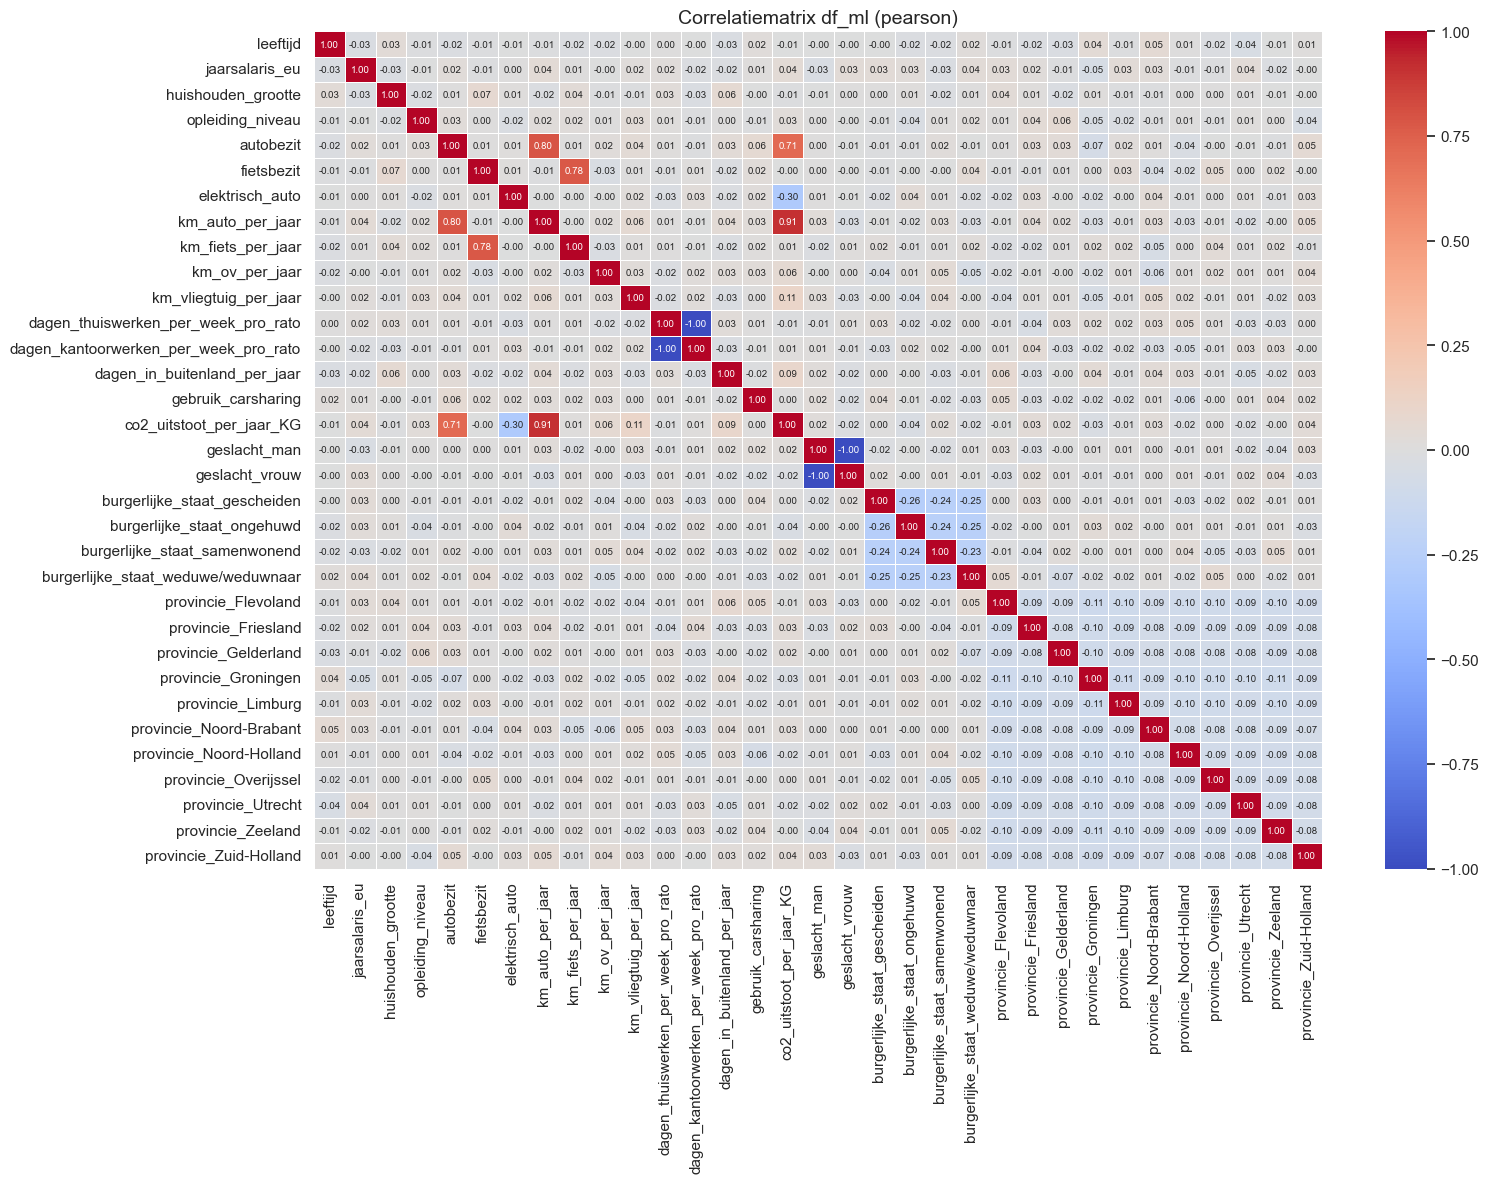

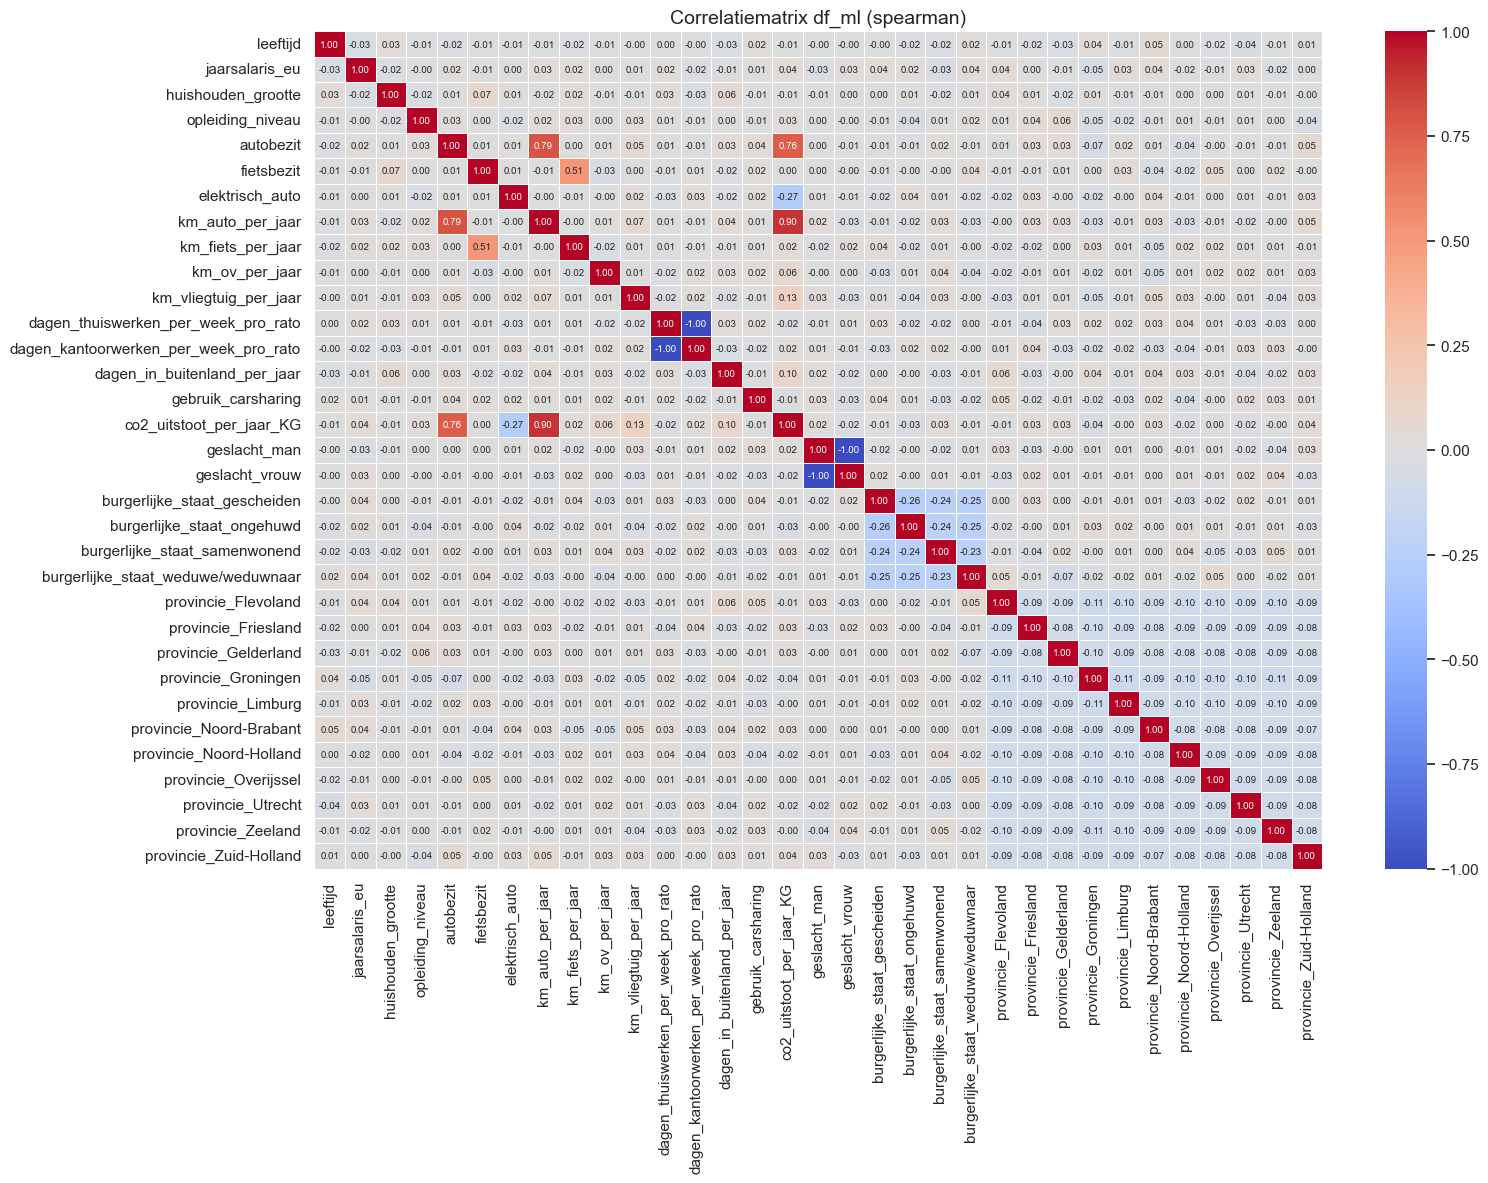

,pearson,spearman
km_auto_per_jaar,0.907072,0.898503
autobezit,0.711172,0.764239
elektrisch_auto,-0.301202,-0.274049
km_vliegtuig_per_jaar,0.105855,0.133074
dagen_in_buitenland_per_jaar,0.087366,0.095140
km_ov_per_jaar,0.060825,0.062723
jaarsalaris_eu,0.042692,0.040289
provincie_Groningen,-0.032817,-0.039329
provincie_Zuid-Holland,0.037964,0.038065
burgerlijke_staat_samenwonend,0.024689,0.034747


In [12]:
# Pearson (lineair) + Spearman (op rangen, robuust tegen de scheve verdelingen uit D)
for methode in ["pearson", "spearman"]:
    corr = df_ml.corr(method=methode, numeric_only=True)
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                linewidths=0.5, annot_kws={"size": 7})
    plt.title(f"Correlatiematrix df_ml ({methode})", fontsize=14)
    plt.tight_layout()
    plt.show()

# Correlatie met de target, beide methodes naast elkaar
target = "co2_uitstoot_per_jaar_KG"
overzicht = pd.DataFrame({
    "pearson": df_ml.corr(method="pearson", numeric_only=True)[target],
    "spearman": df_ml.corr(method="spearman", numeric_only=True)[target],
}).drop(index=target)
overzicht.reindex(overzicht["spearman"].abs().sort_values(ascending=False).index)

---
## Deel 4 — Kansrekening *(Jafari)*

### G — Wat is de kans dat een willekeurig persoon 5000 kg CO₂ uitstoot? Gebruik de **standaard normaalverdeling**
*Stappenplan: μ en σ van de uitstoot bepalen → z-score van 5000 berekenen → kans via `stats.norm`. Let op: bij een continue verdeling is P(X = exact 5000) ≈ 0; kies en onderbouw een interpretatie (P(X ≤ 5000), P(X ≥ 5000) of een klein interval) — beschrijf dit in verslagvraag 9.*

In [13]:
mu = df_clean["co2_uitstoot_per_jaar_KG"].mean()
sigma = df_clean["co2_uitstoot_per_jaar_KG"].std()
z = (5000 - mu) / sigma
print(f"mu = {mu:.2f}, sigma = {sigma:.2f}, z = {z:.4f}")

# standaardnormaal
kans_kleiner = stats.norm.cdf(z)        
kans_groter = 1 - stats.norm.cdf(z)    

print(f"P(X ≤ 5000) = {kans_kleiner:.4f}")
print(f"P(X ≥ 5000) = {kans_groter:.4f}")

mu = 4912.34, sigma = 3422.90, z = 0.0256
P(X ≤ 5000) = 0.5102
P(X ≥ 5000) = 0.4898


---
## Deel 5 — Hypothesetoetsing: verschil tussen groepen *(Jafari)*

**Opdracht:** kies een categoriale variabele (minimaal 2 groepen, **niet geslacht**) en onderzoek of de CO₂-uitstoot verschilt tussen de groepen. Hypothesen, foutentypes en toetskeuze komen in verslagvragen 10–12.

**Onze keuze:** `autobezit` — 2 groepen (ja / nee). Één groep blijkt niet normaal verdeeld (Shapiro-Wilk, zie I), dus toetsen we het verschil met de **Mann-Whitney U-toets** i.p.v. de onafhankelijke t-toets.

### H — Maak geschikte plots om het verschil tussen de groepen te visualiseren

C:\Users\thoma\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


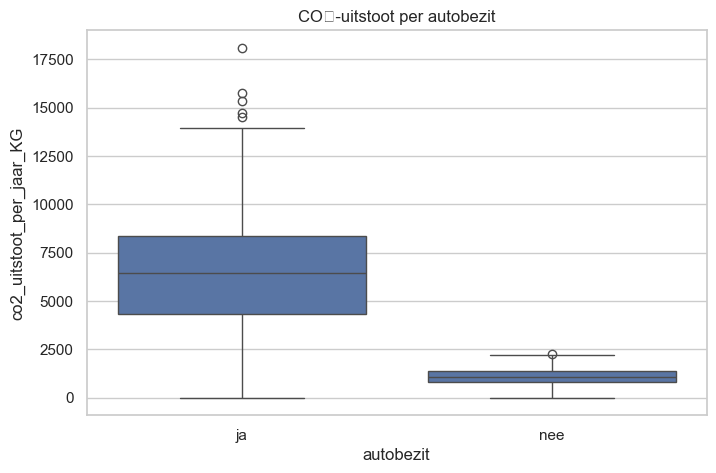

C:\Users\thoma\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


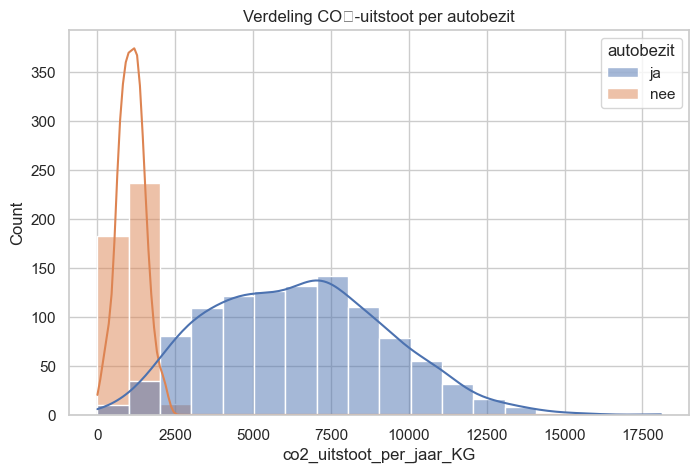

In [14]:
groep_var = "autobezit"  

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x=groep_var, y="co2_uitstoot_per_jaar_KG")
plt.title("CO₂-uitstoot per autobezit")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x="co2_uitstoot_per_jaar_KG", hue=groep_var, kde=True)
plt.title("Verdeling CO₂-uitstoot per autobezit")
plt.show()

### I — Voer de toets uit

In [15]:
groep_var = "autobezit"

# Verwijder rijen waar autobezit NaN is
df_toets = df_clean.dropna(subset=[groep_var, "co2_uitstoot_per_jaar_KG"])


groepen = [g["co2_uitstoot_per_jaar_KG"].values for _, g in df_toets.groupby(groep_var)]

for naam, groep in df_toets.groupby(groep_var):
    stat, p = stats.shapiro(groep["co2_uitstoot_per_jaar_KG"])
    print(f"Shapiro-Wilk {naam}: p = {p:.4f} → {'niet normaal' if p < 0.05 else 'normaal'}")

stat, p = stats.mannwhitneyu(*groepen)
print(f"\nMann-Whitney U: statistiek = {stat:.2f}, p-waarde = {p:.4f}")

if p < 0.05:
    print("Conclusie: p < 0.05 → H0 verwerpen, significant verschil")
else:
    print("Conclusie: p >= 0.05 → H0 niet verwerpen, geen significant verschil")

Shapiro-Wilk ja: p = 0.0000 → niet normaal
Shapiro-Wilk nee: p = 0.4253 → normaal

Mann-Whitney U: statistiek = 451704.00, p-waarde = 0.0000
Conclusie: p < 0.05 → H0 verwerpen, significant verschil


---
## Deel 6 — Lineaire regressie *(Thomas)*

### J — Splits de data in een train- en testset (kies zelf een geschikte split)

In [16]:
# Deel 6 — J: data splitsen in train- en testset
# df_ml bevat nog enkele missende waarden (jaarsalaris, autobezit en de target co2);
# een lineair model kan daar niet mee rekenen, dus modelleren we op de complete rijen.
df_model = df_ml.dropna()
print("rijen voor/na verwijderen NaN:", len(df_ml), "->", len(df_model))

X = df_model.drop(columns=["co2_uitstoot_per_jaar_KG"])
y = df_model["co2_uitstoot_per_jaar_KG"]

# 80/20-split met vaste random_state, zodat het resultaat reproduceerbaar is
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

rijen voor/na verwijderen NaN: 1493 -> 1493
(1194, 32) (299, 32)


In [17]:
# Hulpberekening voor verslagvraag 15: aantal mogelijke splits
from math import comb
from decimal import Decimal
n = len(df_model)
k = len(X_test)
aantal = comb(n, k)
# Decimal i.p.v. float: C(n, k) is veel groter dan een float aankan
print(f"n = {n}, k = {k}")
print(f"C({n}, {k}) = {Decimal(aantal):.4e}")

n = 1493, k = 299
C(1493, 299) = 1.2999e+323


### K — Train een lineair regressiemodel om de jaarlijkse CO₂-uitstoot te voorspellen

In [18]:
# Deel 6 — K: lineair regressiemodel trainen
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"R²   op testset: {r2_score(y_test, y_pred):.4f}")
print(f"MAE  op testset: {mean_absolute_error(y_test, y_pred):.1f} kg")
print(f"RMSE op testset: {mean_squared_error(y_test, y_pred)**0.5:.1f} kg")
print("intercept (b0):", round(lr.intercept_, 2))

# Coëfficiënten gesorteerd op grootte (= formule van het model)
coefs = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coefs

R²   op testset: 0.9145
MAE  op testset: 683.9 kg
RMSE op testset: 1016.5 kg
intercept (b0): 306.36


elektrisch_auto                         -2537.304605
autobezit                                -208.471799
geslacht_vrouw                            175.356876
provincie_Noord-Brabant                   172.166368
provincie_Friesland                       171.864517
provincie_Overijssel                      169.923671
provincie_Utrecht                         139.909441
provincie_Gelderland                      137.039150
provincie_Limburg                         122.317908
geslacht_man                              118.410711
burgerlijke_staat_ongehuwd                -99.909277
provincie_Zeeland                          97.501205
provincie_Zuid-Holland                     97.436067
provincie_Noord-Holland                    91.335958
provincie_Groningen                        80.844350
burgerlijke_staat_weduwe/weduwnaar         68.610302
gebruik_carsharing                        -61.781429
provincie_Flevoland                        59.682526
dagen_kantoorwerken_per_week_pro_rato      33.

In [19]:
# Hulpberekening voor verslagvraag 17: voorspelling voor 1 groepsgenoot
# Model:  ŷ = b0 + b1·x1 + b2·x2 + ... + bp·xp   (intercept + coëfficiënten uit cel K)
#
# We vullen de ECHTE situatie van een groepsgenoot in. Kolommen/encoding moeten exact
# gelijk zijn aan X. We starten van een bestaande rij (voor de juiste dummy-kolommen)
# en zetten alle relevante waarden naar de echte situatie van de groepsgenoot.
groepsgenoot = X_test.iloc[[0]].copy()

# Thomas: student, geen auto, reist met fiets/OV en af en toe vliegtuig
groepsgenoot["leeftijd"] = 19
groepsgenoot["jaarsalaris_eu"] = 0
groepsgenoot["autobezit"] = 0
groepsgenoot["elektrisch_auto"] = 0
groepsgenoot["km_auto_per_jaar"] = 0
groepsgenoot["fietsbezit"] = 1
groepsgenoot["km_fiets_per_jaar"] = 2500
groepsgenoot["km_ov_per_jaar"] = 4000
groepsgenoot["km_vliegtuig_per_jaar"] = 3000
groepsgenoot["dagen_in_buitenland_per_jaar"] = 14

voorspelling = lr.predict(groepsgenoot)[0]
print(f"Voorspelde CO₂-uitstoot (Thomas): {voorspelling:.0f} kg")

Voorspelde CO₂-uitstoot (Thomas): 1944 kg


### L — Bepaal welke 5 onafhankelijke variabelen de meeste invloed hebben op de voorspelling
*Let op: coëfficiënten zijn alleen vergelijkbaar als de features op dezelfde schaal staan → standaardiseer eerst (of train op gestandaardiseerde X) en kijk dan naar |coëfficiënt|.*

In [20]:
# Deel 6 — L: de 5 invloedrijkste variabelen bepalen
# Coëfficiënten zijn alleen vergelijkbaar als de features dezelfde schaal hebben,
# daarom standaardiseren we X eerst (gemiddelde 0, std 1) en kijken we naar |coëfficiënt|.
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)

lr_s = LinearRegression().fit(X_train_s, y_train)
belang = pd.Series(lr_s.coef_, index=X.columns).abs().sort_values(ascending=False)

top5_features = list(belang.head(5).index)
print("Top-5 invloedrijkste variabelen:")
for i, f in enumerate(top5_features, 1):
    print(f"{i}. {f}  (|gestand. coëf| = {belang[f]:.1f})")
belang.head(5)

Top-5 invloedrijkste variabelen:
1. km_auto_per_jaar  (|gestand. coëf| = 3145.3)
2. elektrisch_auto  (|gestand. coëf| = 992.3)
3. km_vliegtuig_per_jaar  (|gestand. coëf| = 181.2)
4. dagen_in_buitenland_per_jaar  (|gestand. coëf| = 147.4)
5. km_ov_per_jaar  (|gestand. coëf| = 141.4)


km_auto_per_jaar                3145.288009
elektrisch_auto                  992.250733
km_vliegtuig_per_jaar            181.207405
dagen_in_buitenland_per_jaar     147.372926
km_ov_per_jaar                   141.418460
dtype: float64

---
## Deel 7 — Modelvergelijking met 20-fold cross-validation *(Thomas)*

### M — Train en test 2 modellen met 20-fold cross-validation
*Model 1: alle variabelen · Model 2: alleen de top-5 variabelen uit L.*

In [21]:
# Deel 7 — M: twee modellen trainen/testen met 20-fold cross-validation
# Metric = R² (zie verslagvraag 16). Dezelfde KFold (vaste folds) voor beide modellen,
# zodat de scores per fold gepaard zijn -> nodig voor de toets in P.
kf = KFold(n_splits=20, shuffle=True, random_state=42)

# Model 1: alle variabelen
scores_alle = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")
# Model 2: alleen de top-5 variabelen uit L
scores_top5 = cross_val_score(LinearRegression(), X[top5_features], y, cv=kf, scoring="r2")

print("20 R²-scores per model berekend.")

20 R²-scores per model berekend.


### N — Kwantificeer de nauwkeurigheid van beide modellen met 1 metric (zie verslagvraag 16)

In [22]:
# Deel 7 — N: nauwkeurigheid kwantificeren met R² (gemiddelde ± standaarddeviatie)
print(f"Model 1 (alle variabelen): R² = {scores_alle.mean():.3f} ± {scores_alle.std():.3f}")
print(f"Model 2 (top-5):           R² = {scores_top5.mean():.3f} ± {scores_top5.std():.3f}")

Model 1 (alle variabelen): R² = 0.917 ± 0.022
Model 2 (top-5):           R² = 0.919 ± 0.022


### O — Visualiseer het verschil in nauwkeurigheid tussen de twee modellen
*Bv. boxplot of histogram van de 2 × 20 CV-scores naast elkaar.*

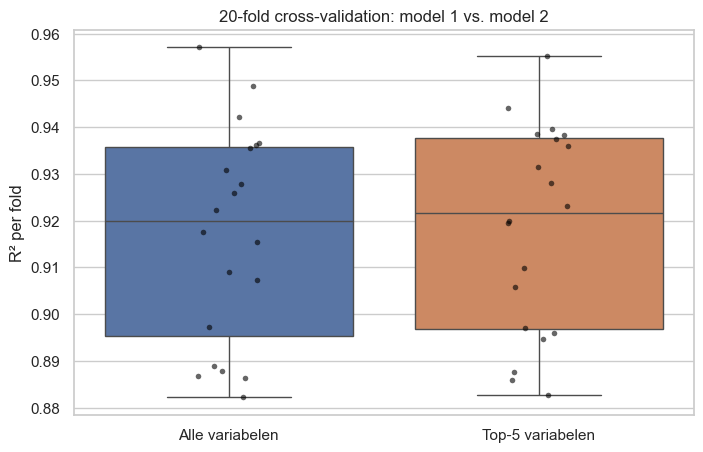

In [23]:
# Deel 7 — O: verschil in nauwkeurigheid visualiseren
cv_scores = pd.DataFrame({
    "Alle variabelen": scores_alle,
    "Top-5 variabelen": scores_top5,
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_scores)
sns.stripplot(data=cv_scores, color="black", size=4, alpha=0.6)
plt.ylabel("R² per fold")
plt.title("20-fold cross-validation: model 1 vs. model 2")
plt.show()

### P — Onderzoek met toetsende statistiek welk model significant beter is
*De 20 scores zijn gepaard (zelfde folds!) → gepaarde t-toets (`stats.ttest_rel`) als de verschillen normaal verdeeld zijn, anders Wilcoxon signed-rank (`stats.wilcoxon`). Check de normaliteit van de verschilscores eerst.*

In [24]:
# Deel 7 — P: toetsen welk model significant beter is
# De 20 scores zijn gepaard (zelfde folds). Eerst de verschilscores op normaliteit
# checken -> bepaalt gepaarde t-toets vs. Wilcoxon signed-rank.
verschillen = scores_alle - scores_top5

sw_stat, sw_p = stats.shapiro(verschillen)
print(f"Shapiro-Wilk op verschilscores: p = {sw_p:.4f} "
      f"-> {'niet normaal' if sw_p < 0.05 else 'normaal'}")

if sw_p >= 0.05:
    stat, p = stats.ttest_rel(scores_alle, scores_top5)
    print(f"Gepaarde t-toets: t = {stat:.3f}, p = {p:.4f}")
else:
    stat, p = stats.wilcoxon(scores_alle, scores_top5)
    print(f"Wilcoxon signed-rank: stat = {stat:.3f}, p = {p:.4f}")

if p < 0.05:
    print("-> p < 0,05: er is een significant verschil tussen de modellen.")
else:
    print("-> p >= 0,05: geen significant verschil. "
          "Model 2 (top-5) is even nauwkeurig maar eenvoudiger -> voorkeur.")

Shapiro-Wilk op verschilscores: p = 0.2187 -> normaal
Gepaarde t-toets: t = -1.507, p = 0.1483
-> p >= 0,05: geen significant verschil. Model 2 (top-5) is even nauwkeurig maar eenvoudiger -> voorkeur.


---
## Deel 8 — Classificatie *(Melih)*

### Q — Splits de targetvariabele in 2 even grote klassen (0 = lage uitstoot, 1 = hoge uitstoot)
*Even grote klassen → afkapwaarde = mediaan.*

In [25]:
# Even grote klassen -> afkapwaarde = mediaan van de uitstoot
afkap = df_ml["co2_uitstoot_per_jaar_KG"].median()
y_klasse = (df_ml["co2_uitstoot_per_jaar_KG"] > afkap).astype(int)
print(f"afkapwaarde (mediaan): {afkap:.2f}")
print(y_klasse.value_counts())

afkapwaarde (mediaan): 4677.28
co2_uitstoot_per_jaar_KG
0    747
1    746
Name: count, dtype: int64


### R — Train een nieuw model op de nieuwe target met alleen de 5 invloedrijkste variabelen
*Modelkeuze onderbouw je in verslagvraag 20.*

In [26]:
# Deel 8 — R: classificatiemodel trainen op alleen de top-5 variabelen
# Hergebruik: top5_features (L), X en y (Deel 6, al dropna), afkap (Q).
# Target binair maken op DEZELFDE rijen als X, anders lopen de indexen niet gelijk.
y_klasse = (y > afkap).astype(int)

# 80/20-split, zelfde random_state als bij regressie -> reproduceerbaar
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X[top5_features], y_klasse, test_size=0.2, random_state=42)

# Logistische regressie (zie verslagvraag 20): geeft kansen via de sigmoidfunctie
logr = LogisticRegression(max_iter=1000).fit(Xc_train, yc_train)
yc_pred = logr.predict(Xc_test)

print(f"accuracy op testset: {accuracy_score(yc_test, yc_pred):.3f}")
print("confusion matrix [rij=werkelijk, kol=voorspeld]:")
print(confusion_matrix(yc_test, yc_pred))
print("intercept (b0):", round(logr.intercept_[0], 4))

# Coëfficiënten = formule van het model (zie verslagvraag 21)
pd.Series(logr.coef_[0], index=top5_features)

accuracy op testset: 0.970


confusion matrix [rij=werkelijk, kol=voorspeld]:


[[140   7]
 [  2 150]]
intercept (b0): -6.8926


km_auto_per_jaar                0.000760
elektrisch_auto                -7.700693
km_vliegtuig_per_jaar           0.000534
dagen_in_buitenland_per_jaar    0.029035
km_ov_per_jaar                  0.000173
dtype: float64

In [27]:
# Hulpberekening voor verslagvraag 21: kans + klasse voor 1 groepsgenoot
# Hergebruik dezelfde groepsgenoot als bij Python K; alleen de top-5 kolommen.
kans = logr.predict_proba(groepsgenoot[top5_features])[0, 1]
klasse = int(logr.predict(groepsgenoot[top5_features])[0])
print(f"P(hoge uitstoot) = {kans:.3f}  ->  klasse {klasse} ({'hoog' if klasse else 'laag'})")

P(hoge uitstoot) = 0.015  ->  klasse 0 (laag)


---
# Verslag (handgeschreven, inleveren bij assessment)

Alle theorievragen op een rij. Vul je antwoord onder je eigen vragen in (zie taakverdeling); 1 persoon schrijft het geheel daarna leesbaar met de hand uit.

---

**Vraag 1 (Melih) — Geef voor elke variabele in de dataset weer tot welk meetniveau deze behoort.**
*(nominaal / ordinaal / interval / ratio)*

| Variabele | Meetniveau |
|---|---|
| persoon_ID | nominaal (label, geen meetwaarde) |
| geslacht | … |
| leeftijd | … |
| gewicht_KG | … |
| burgerlijke_staat | … |
| jaarsalaris_eu | … |
| huishouden_grootte | … |
| stad | … |
| provincie | … |
| opleiding_niveau | … (MBO < HBO < WO heeft een volgorde) |
| autobezit / fietsbezit / elektrisch_auto | … |
| km_auto / km_fiets / km_ov / km_vliegtuig per jaar | … |
| dagen_thuiswerken / dagen_kantoorwerken per week | … |
| dagen_in_buitenland_per_jaar | … |
| gebruik_carsharing | … (Nooit / Heel soms / … → volgorde?) |
| co2_uitstoot_per_jaar_KG | … |

**Vraag 2 (Melih) — Waarom is het nodig om vooraf het meetniveau van elke variabele te bekijken?**

> *Antwoord: … (denk aan: welke statistieken zijn toegestaan — gemiddelde van nominale data is zinloos; welke grafieken passen; welke toetsen mogen; welke ML-transformatie nodig is)*

**Vraag 3 (Melih) — Hoe ben je omgegaan met missende/niet-kloppende/extreme waarden in de dataset?** *(zie Python B)*

> *Antwoord: … (per type probleem: wat gevonden, welke keuze — verwijderen/corrigeren/imputeren — en waarom)*

**Vraag 4 (Melih) — Geef een beschrijving van de 3 visualisaties met behulp van statistische termen.** *(zie Python C)*

> *Antwoord: … (per verdeling: symmetrisch of scheef links/rechts, modaliteit, centrum gemiddelde vs. mediaan, spreiding, uitschieters)*

**Vraag 5 (Melih) — Wat is de conclusie met betrekking tot de drie verdelingen?** *(zie Python D)*

> *Antwoord: … (per variabele: p-waarde vs. α = 0,05 → H0 verwerpen of niet → wel/niet normaal verdeeld)*

**Vraag 6 (Jafari) — Om onafhankelijke variabelen te gebruiken voor Machine Learning moeten ze getransformeerd worden. Geef per meetniveau aan wat er moet gebeuren.**

> *Antwoord:*
> - *Nominaal → … (one-hot encoding / dummies)*
> - *Ordinaal → … (codering die de volgorde behoudt)*
> - *Interval/ratio → … (schalen/standaardiseren)*

**Vraag 7 (Jafari) — Wat kun je zeggen over de relaties tussen de variabelen?** *(zie Python F)*

> *Antwoord: … (welke variabelen correleren sterk met CO₂-uitstoot — richting + sterkte; onderlinge correlatie / multicollineariteit)*

**Vraag 8 (Jafari) — Welke methode(n) heb je gebruikt en waarom?**

> *Antwoord: … (Pearson — lineair, interval/ratio vs. Spearman — monotoon, ordinaal/niet-normaal; koppel aan conclusie vraag 5)*

**Vraag 9 (Jafari) — Geef een korte beschrijving van hoe je de kans op 5000 kg CO₂-uitstoot hebt berekend.** *(zie Python G)*

> *Antwoord: … (μ en σ → z-score → standaardnormaalverdeling → interpretatie van de gekozen kans)*

**Vraag 10 (Jafari) — Stel de hypothesen op.** *(groepsvergelijking, zie Deel 5)*

> *H0: …*
> *H1: …*

**Vraag 11 (Jafari) — Welke type fouten kunnen er gemaakt worden?**

> *Antwoord: … (Type I (α): H0 onterecht verwerpen → concreet voor onze situatie; Type II (β): H0 onterecht behouden → …)*

**Vraag 12 (Jafari) — Welke statistische toets moet je uitvoeren om te onderzoeken of er een significant verschil is?**

> *Antwoord: … (2 groepen + normaal → onafhankelijke t-toets; niet normaal → Mann-Whitney U; > 2 groepen → ANOVA / Kruskal-Wallis; onderbouw met normaliteitscheck per groep)*

**Vraag 13 (Jafari) — Geef in eigen woorden een toelichting op de betekenis van de p-waarde.**

> *Antwoord: … (de kans om — als H0 waar is — een resultaat te vinden dat minstens zo extreem is als het waargenomen resultaat; NIET de kans dat H0 waar is)*

**Vraag 14 (Jafari) — Welke conclusie kun je trekken op basis van de statistische toets?** *(zie Python I)*

> *Antwoord: … (p vs. α = 0,05 → H0 wel/niet verwerpen → betekenis voor de CO₂-uitstoot van de groepen)*

**Vraag 15 (Thomas) — Op hoeveel verschillende manieren kan de train/test-split gemaakt worden? Gebruik wetenschappelijke notatie.** *(zie hulpberekening bij Python J)*

> *Antwoord: … (combinatoriek: C(n, k) = n! / (k!(n−k)!) met n = …, k = … → a × 10^b)*

**Vraag 16 (Thomas) — Welke metric zou je gebruiken om te toetsen hoe goed je model is en waarom?**

> *Antwoord: … (R² — verklaarde variantie; MAE — gemiddelde absolute fout in kg, goed interpreteerbaar; RMSE — straft grote fouten zwaarder; kies + onderbouw)*

**Vraag 17 (Thomas) — Geef de wiskundige formule van het getrainde regressiemodel en pas deze toe op 1 groepsgenoot.** *(zie Python K + hulpberekening)*

> *Antwoord: ŷ = b0 + b1·x1 + b2·x2 + … met ingevulde coëfficiënten en de echte gegevens van een groepsgenoot → voorspelde uitstoot = … kg*

**Vraag 18 (Thomas) — Welke statistische toets(en) heb je gebruikt bij de modelvergelijking en waarom?** *(zie Python P)*

> *Antwoord: … (gepaard vs. ongepaard — waarom gepaard hier; normaliteitscheck van de verschilscores → keuze toets)*

**Vraag 19 (Thomas) — Wat is de conclusie van de statistische toets?**

> *Antwoord: … (p vs. α → wel/geen significant verschil → welk model kiezen we: eenvoud vs. nauwkeurigheid)*

**Vraag 20 (Melih) — Welk model zou je nu kunnen gebruiken (binaire target) en waarom?**

> *Antwoord: … (binaire target → classificatie i.p.v. regressie → logistische regressie: geeft kansen tussen 0 en 1 via de sigmoidfunctie)*

**Vraag 21 (Melih) — Geef de wiskundige formule van het getrainde classificatiemodel en pas deze toe op 1 groepsgenoot.** *(zie Python R + hulpberekening)*

> *Antwoord: P(hoge uitstoot) = 1 / (1 + e^−(b0 + b1·x1 + … + b5·x5)) met ingevulde waarden → kans = …, klasse = …*

**Vraag 22 (samen) — Schrijf een conclusie op basis van de twee hoofdvragen van het portfolio.**

> *Antwoord:*
> 1. *Welke factoren verklaren verschillen in CO₂-uitstoot? → top-5 variabelen (Python L), correlaties (Deel 3), groepsverschil (Deel 5)*
> 2. *Hoe nauwkeurig kunnen we voorspellen? → metric-scores en modelvergelijking (Deel 6–7), classificatieprestatie (Deel 8)*

---

## Checklist voor inleveren (21 juni 23:59)
- [ ] Notebook draait foutloos van boven naar beneden (*Kernel → Restart & Run All*)
- [ ] Alle Python-opdrachten (A t/m R) af, alle TODO's weg
- [ ] Alle verslagvragen (1 t/m 22) ingevuld → overgeschreven in het handgeschreven verslag
- [ ] Notebook geüpload op Brightspace (1x per groep)
- [ ] Gezamenlijke doorloopsessie gepland — iedereen kan elk deel uitleggen (5 vragen p.p., 1 per leerdoel)
- [ ] Handgeschreven verslag mee naar het assessment